Machine learning is a branch of Artificial Intelligence that focuses on developing models and algorithms that let computers learn from data without being explicitly programmed for every task. In simple words, ML teaches systems to think and understand like humans by learning from the data.

### Data Preprocessing
- Introduction
- ML workflow
- Data Cleaning
- Data Preprocessing in Python
- Feature Scaling
- Feature Extraction
- Feature Engineering
- Feature Selection Techniques
- 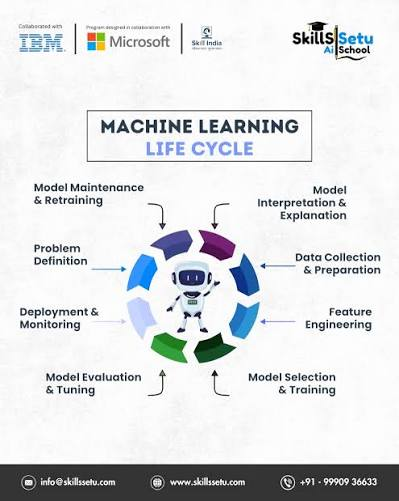

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Data/big_mart_sales.csv")
df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [16]:
df.shape

(8523, 12)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [14]:
df.duplicated().sum()

np.int64(0)

In [18]:
for col in df.select_dtypes(include="object"):
    print("\n", col)
    print(df[col].value_counts())


 Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
NCF42     9
FDW26     9
FDX31     9
         ..
FDY43     1
FDO33     1
FDK57     1
FDQ60     1
FDN52     1
Name: count, Length: 1559, dtype: int64

 Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

 Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

 Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OU

In [19]:
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular",
    "regular": "Regular"
})

In [21]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [30]:
df["Item_Weight"] = df["Item_Weight"].fillna(
    df["Item_Weight"].median()
)

In [31]:
df["Outlet_Size"] = df["Outlet_Size"].fillna(
    df["Outlet_Size"].mode()[0]
)

In [32]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

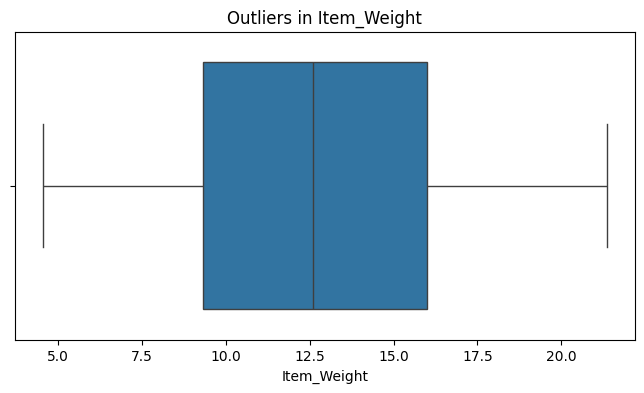

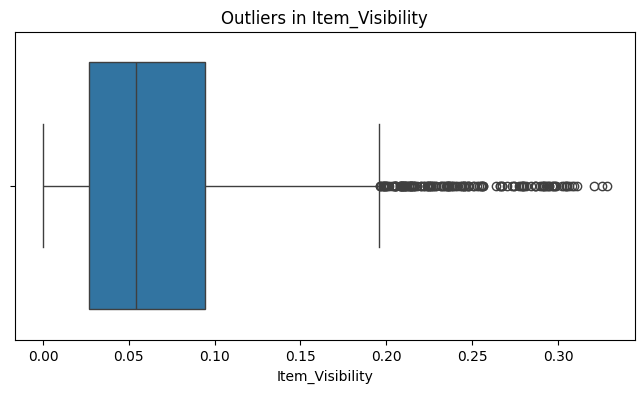

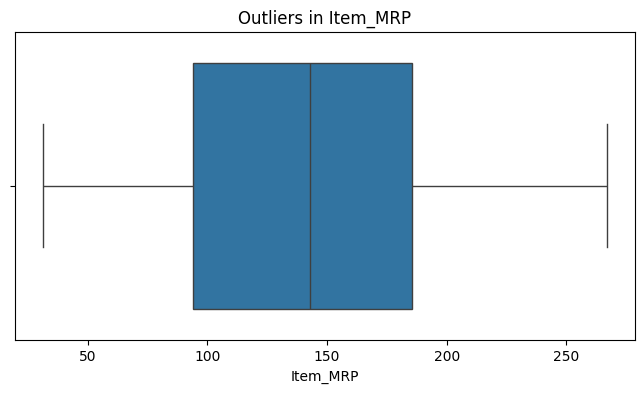

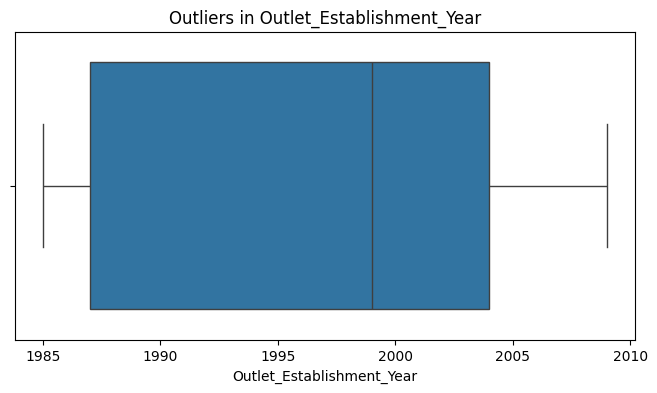

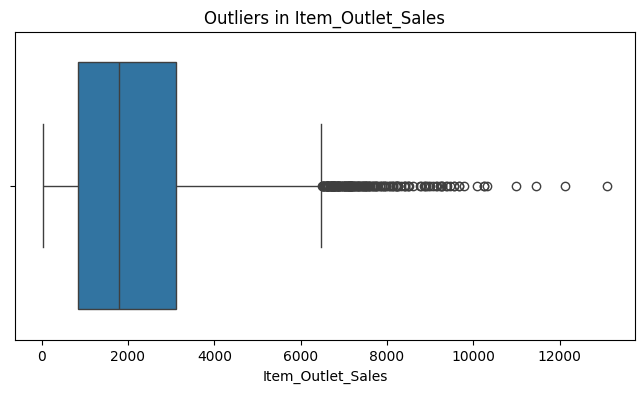

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year",
    "Item_Outlet_Sales"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [34]:
Q1 = df["Item_Outlet_Sales"].quantile(0.25)
Q3 = df["Item_Outlet_Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Item_Outlet_Sales"] < lower) |
    (df["Item_Outlet_Sales"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 186


In [35]:
df["Outlet_Age"] = 2026 - df["Outlet_Establishment_Year"]

In [36]:
print((df["Item_Visibility"] == 0).sum())

526


In [37]:
df["Low_Visibility"] = (
    df["Item_Visibility"] < df["Item_Visibility"].median()
).astype(int)

In [38]:
df["MRP_Category"] = pd.cut(
    df["Item_MRP"],
    bins=[0, 70, 140, 200, 300],
    labels=["Low", "Medium", "High", "Very High"]
)

In [39]:
y = df["Item_Outlet_Sales"]

In [40]:
X = df.drop("Item_Outlet_Sales", axis=1)

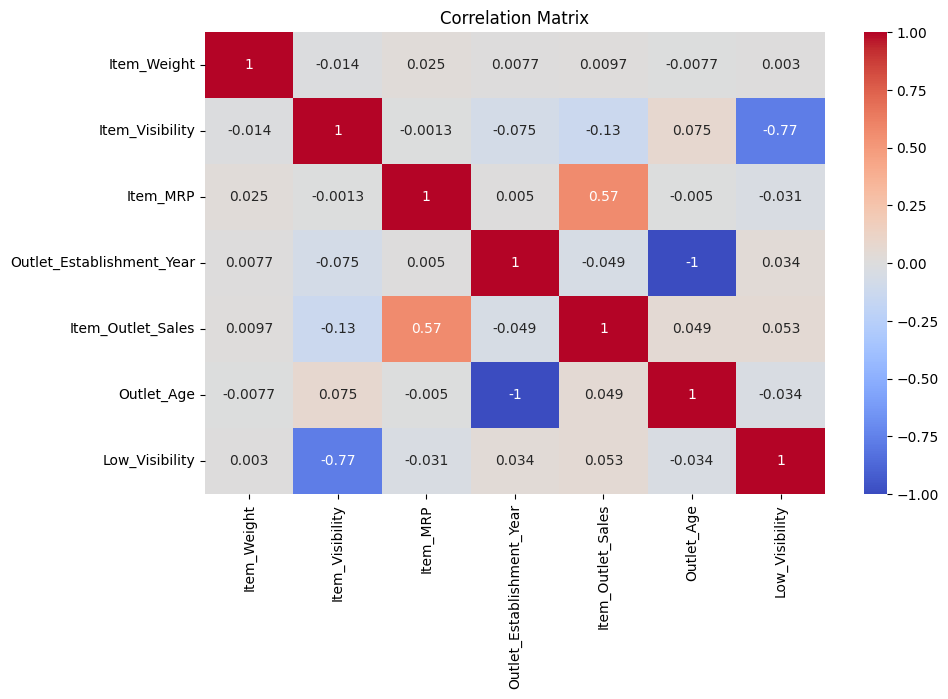

In [41]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [42]:
from sklearn.ensemble import RandomForestRegressor

X_temp = pd.get_dummies(X, drop_first=True)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_temp, y)

importance = pd.Series(
    model.feature_importances_,
    index=X_temp.columns
).sort_values(ascending=False)

print(importance.head(15))

Item_MRP                           0.397698
Outlet_Type_Supermarket Type1      0.098044
Item_Visibility                    0.058126
Outlet_Identifier_OUT027           0.053343
Outlet_Type_Supermarket Type3      0.052592
Item_Weight                        0.030104
Outlet_Establishment_Year          0.029881
Outlet_Age                         0.022648
Outlet_Identifier_OUT018           0.014815
Outlet_Type_Supermarket Type2      0.013975
Outlet_Identifier_OUT045           0.004311
Item_Fat_Content_Regular           0.004250
Outlet_Identifier_OUT049           0.004031
Item_Type_Fruits and Vegetables    0.003926
Outlet_Size_Small                  0.003883
dtype: float64


In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[numeric_features]
)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print(pca.explained_variance_ratio_)

(8523, 2)
[0.26977544 0.25533169]


In [44]:
from sklearn.model_selection import train_test_split

X = df.drop("Item_Outlet_Sales", axis=1)
y = df["Item_Outlet_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6818, 14)
(1705, 14)


In [45]:
numeric_features = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year"
]

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

In [50]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)

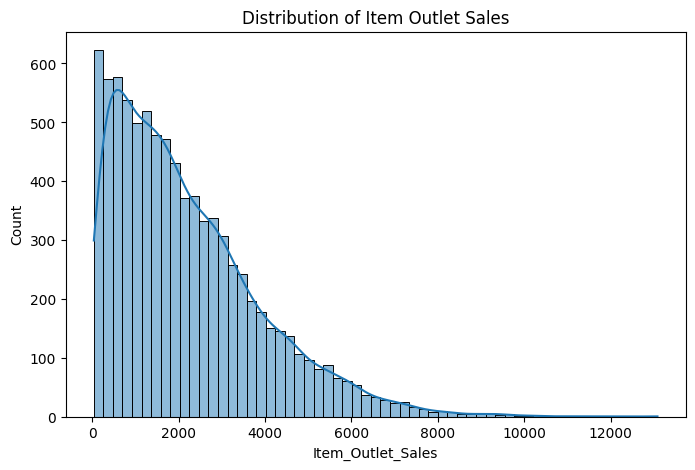

In [51]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Item_Outlet_Sales"],
    kde=True
)

plt.title("Distribution of Item Outlet Sales")
plt.show()

In [52]:
print(df["Item_Outlet_Sales"].skew())

1.1775306028542796


In [53]:
y_log = np.log1p(y)

In [70]:
y_log

0       8.225808
1       6.096776
2       7.648868
3       6.597664
4       6.903451
          ...   
8518    7.929984
8519    6.310436
8520    7.085159
8521    7.521100
8522    6.642056
Name: Item_Outlet_Sales, Length: 8523, dtype: float64